<a href="https://colab.research.google.com/github/Yogi-Puvvala/twitter_sentiment_analysis/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pickle

In [2]:
with open("X_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open("X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open("y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open("y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

In [4]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, SpatialDropout1D, Input

In [9]:
model = Sequential()

model.add(Input(shape = (100, )))
model.add(Embedding(input_dim = 10000, output_dim = 128))
model.add(SpatialDropout1D(0.1))

model.add(LSTM(64, return_sequences = True))
model.add(Dropout(0.1))
model.add(LSTM(32))
model.add(Dropout(0.1))

model.add(Dense(3, activation = "softmax"))

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341,923 (5.12 MB)

 Trainable params: 1,341,923 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss = "sparse_categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [12]:
history = model.fit(X_train, y_train, validation_data = [X_test, y_test], epochs = 30, batch_size = 32, verbose = 1)

Epoch 1/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3667 - loss: 1.0958 - val_accuracy: 0.3686 - val_loss: 1.0953
Epoch 2/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3682 - loss: 1.0954 - val_accuracy: 0.3686 - val_loss: 1.0951
Epoch 3/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3679 - loss: 1.0952 - val_accuracy: 0.3686 - val_loss: 1.0949
Epoch 4/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.3686 - loss: 1.0951 - val_accuracy: 0.3686 - val_loss: 1.0950
Epoch 5/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3685 - loss: 1.0951 - val_accuracy: 0.3686 - val_loss: 1.0949
Epoch 6/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.3686 - loss: 1.0950 - val_accuracy: 0.3686 - val_loss: 1.0950
Epoch 7/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3686 - loss: 1.0950 - val_accuracy: 0.3686 - val_loss: 1.0951
Epoch 8/30
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3686 -

In [13]:
history = history.history

In [14]:
import matplotlib.pyplot as plt

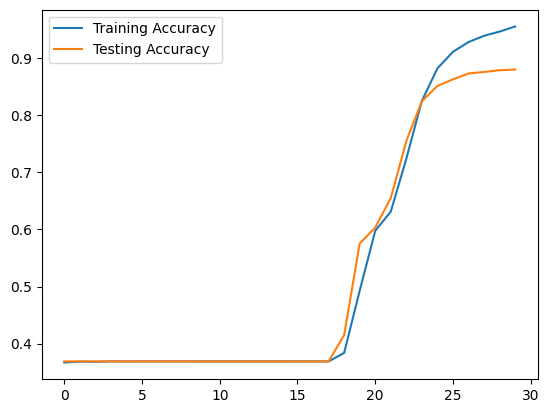

In [17]:
plt.plot(history["accuracy"], label = "Training Accuracy")
plt.plot(history["val_accuracy"], label = "Testing Accuracy")
plt.legend()

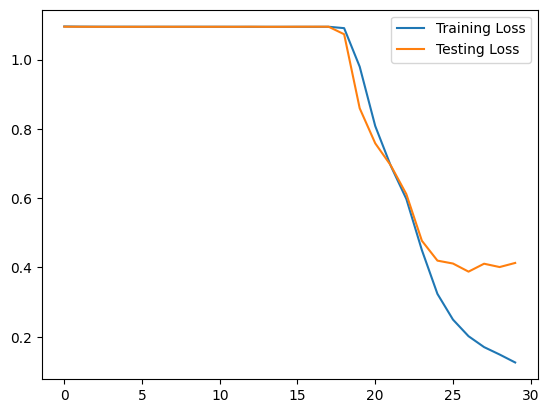

In [18]:
plt.plot(history["loss"], label = "Training Loss")
plt.plot(history["val_loss"], label = "Testing Loss")
plt.legend()

In [19]:
model.save('/content/drive/My Drive/ML_Models/model.keras')